# Feature Engineering

### Configuration

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
from pathlib import Path

IN_DIR      = Path('../data/processed/keypoints_normalized')
IN_DIR_COMB = Path('../data/processed/keypoints_combined')

time_dict = {
  '028': (9.90, 9.92, 9.92, 11.12, 11.19, 11.77), 
  '030': (5.80, 6.25, 6.32, 6.70, 6.76, 7.63),
  '045': (6.54, 6.70, 6.70, 7.29, 7.45, 7.98), 
  '047': (7.03, 7.41, 7.49, 7.79, 7.97, 8.91),
  '059': (6.65, 6.88, 6.90, 7.96, 8.19, 9.11), 
  '061': (6.00, 7.00, 7.00, 8.30, 8.40, 9.00),
  '074': (6.07, 6.33, 6.35, 6.71, 6.90, 7.27), 
  '076': (5.00, 6.00, 6.00, 6.71, 6.90, 8.00),
  '091': (6.39, 6.55, 6.60, 7.03, 7.18, 7.61), 
  '093': (5.86, 5.92, 6.20, 6.65, 6.92, 7.67),
}

## Utgångsposition

In [25]:
def get_phase(df, t_start, t_end):
    return df[(df['time'] >= t_start) & (df['time'] <= t_end)].reset_index(drop=True)

def xy(df, joint):
    return df[[f'{joint}_x', f'{joint}_y']].values

def compute_angle(A, B, C):
    BA = A - B
    BC = C - B
    dot  = (BA * BC).sum(axis=1)
    norm = np.linalg.norm(BA, axis=1) * np.linalg.norm(BC, axis=1)
    return np.degrees(np.arccos(np.clip(dot / norm, -1, 1)))

In [26]:
def extract_utgångsposition(df):
    ls, rs = xy(df, 'left_shoulder'), xy(df, 'right_shoulder')
    lh, rh = xy(df, 'left_hip'),      xy(df, 'right_hip')
    lk, rk = xy(df, 'left_knee'),     xy(df, 'right_knee')
    la, ra = xy(df, 'left_ankle'),     xy(df, 'right_ankle')
    nose   = xy(df, 'nose')

    left_knee_a  = compute_angle(lh, lk, la)
    right_knee_a = compute_angle(rh, rk, ra)
    left_hip_a   = compute_angle(ls, lh, lk)
    right_hip_a  = compute_angle(rs, rh, rk)

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    trunk_vec    = mid_shoulder - mid_hip
    vertical     = np.array([0, -1])
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    return {
        'mean_left_knee_angle':  left_knee_a.mean(),
        'mean_right_knee_angle': right_knee_a.mean(),
        'delta_knee_angle':      np.abs(left_knee_a - right_knee_a).mean(),
        'mean_left_hip_angle':   left_hip_a.mean(),
        'mean_right_hip_angle':  right_hip_a.mean(),
        'delta_hip_angle':       np.abs(left_hip_a - right_hip_a).mean(),
        'mean_trunk_angle':      trunk_a.mean(),
        'mean_head_trunk_angle': head_trunk_a.mean(),
        'delta_hip_height':      np.abs(lh[:, 1] - rh[:, 1]).mean(),
    }

In [27]:
OUT_DIR = Path('../data/processed/features')
OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []
for vid_id, times in time_dict.items():
    t0, t1 = times[0], times[1]
    df = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    phase = get_phase(df, t0, t1)
    rows.append({'video': vid_id, **extract_utgångsposition(phase)})

df_utgång = pd.DataFrame(rows).set_index('video')
df_utgång.to_csv(OUT_DIR / 'utgångsposition.csv')
display(df_utgång.round(2))

,mean_left_knee_angle,mean_right_knee_angle,delta_knee_angle,mean_left_hip_angle,mean_right_hip_angle,delta_hip_angle,mean_trunk_angle,mean_head_trunk_angle,delta_hip_height
video,,,,,,,,,
028,127.78,114.56,13.21,142.60,127.95,14.65,8.53,158.42,0.06
030,126.93,118.38,8.55,139.16,128.25,10.91,2.88,158.05,0.04
045,123.38,118.73,4.65,133.32,124.69,8.63,5.69,157.61,0.03
047,127.21,123.18,4.03,134.29,124.32,9.97,0.48,160.64,0.03
059,119.05,119.47,1.00,135.71,135.17,0.84,9.65,156.18,0.10
061,137.76,125.07,12.69,146.67,131.15,15.52,0.44,160.89,0.06
074,114.83,113.85,1.00,137.07,129.21,7.86,10.44,152.90,0.06
076,126.02,119.83,6.19,137.61,126.28,11.33,0.51,160.10,0.05
091,127.45,114.65,12.80,143.49,129.37,14.11,12.26,158.54,0.11


## Rörelsestart

In [28]:
def extract_rörelsestart(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')

    mid_shoulder = (ls + rs) / 2
    mid_hip_norm = (lh + rh) / 2

    vertical  = np.array([0, -1])
    trunk_vec = mid_shoulder - mid_hip_norm
    trunk_a   = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_x   = ((lh_c + rh_c) / 2)[:, 0]
    hip_vel     = np.diff(mid_hip_x) / dt

    trunk_peak = np.argmax(trunk_a)
    hip_peak   = np.argmin(mid_hip_x)

    return {
        'initial_trunk_angle':         trunk_a[0],
        'max_trunk_angle':             trunk_a.max(),
        'delta_trunk_flexion':         trunk_a.max() - trunk_a[0],
        'max_trunk_angular_velocity':  np.abs(velocity).max(),
        'mean_trunk_angular_velocity': np.abs(velocity).mean(),
        'hip_forward_displacement':    mid_hip_x[0] - mid_hip_x[-1],
        'peak_hip_velocity':           np.abs(hip_vel).max(),
        'trunk_hip_correlation':       np.corrcoef(trunk_a, mid_hip_x)[0, 1],
        'trunk_hip_time_lag':          (hip_peak - trunk_peak) / 50.0,
        'rms_angular_acceleration':    np.sqrt(np.mean(acceleration ** 2)),
    }

In [29]:
rows = []
for vid_id, times in time_dict.items():
    t1, t5 = times[1], times[5]
    df_norm = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_norm = get_phase(df_norm, t1, t5)
    phase_comb = get_phase(df_comb, t1, t5)
    rows.append({'video': vid_id, **extract_rörelsestart(phase_norm, phase_comb)})

df_rörelse = pd.DataFrame(rows).set_index('video')
df_rörelse.to_csv(OUT_DIR / 'rörelsestart.csv')
display(df_rörelse.round(4))

,initial_trunk_angle,max_trunk_angle,delta_trunk_flexion,max_trunk_angular_velocity,mean_trunk_angular_velocity,hip_forward_displacement,peak_hip_velocity,trunk_hip_correlation,trunk_hip_time_lag,rms_angular_acceleration
video,,,,,,,,,,
028,8.5082,20.5918,12.0837,81.7114,27.5236,0.0551,0.1832,-0.1885,0.42,1174.5605
030,2.1448,25.4528,23.3080,77.9225,38.7613,0.0429,0.1195,0.3695,0.64,746.5511
045,5.6739,22.5825,16.9086,80.5183,34.3558,0.0426,0.1119,-0.3874,0.50,968.4275
047,0.6311,23.7369,23.1058,74.9381,31.8190,0.0484,0.1261,0.5495,0.92,625.1623
059,9.6842,29.9735,20.2893,99.5038,30.7214,0.0641,0.1493,-0.0975,0.90,884.1634
061,0.0526,18.7616,18.7090,55.6288,18.5732,0.0440,0.1116,-0.1649,0.62,449.3383
074,9.7014,11.6550,1.9536,67.7181,33.3541,0.0442,0.1633,-0.1231,0.36,1055.6446
076,1.3279,21.4890,20.1611,92.1273,22.1029,0.0497,0.1842,0.7636,1.08,640.3532
091,12.1492,14.6302,2.4811,91.4901,35.1403,0.0465,0.1553,-0.0038,0.32,1330.3905


## Rörelseutförande

### Förberedelsefas

In [30]:
def extract_förberedelsefas(df_norm, df_comb):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    nose   = xy(df_norm, 'nose')
    lw, rw = xy(df_norm, 'left_wrist'),    xy(df_norm, 'right_wrist')

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2

    vertical  = np.array([0, -1])
    trunk_vec = mid_shoulder - mid_hip
    trunk_a   = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt           = 1 / 50
    velocity     = np.diff(trunk_a) / dt
    acceleration = np.diff(velocity) / dt

    lh_c, rh_c = xy(df_comb, 'left_hip'), xy(df_comb, 'right_hip')
    mid_hip_x   = ((lh_c + rh_c) / 2)[:, 0]

    head_trunk_a = compute_angle(mid_hip, mid_shoulder, nose)

    lw_acc = np.diff(np.diff(lw, axis=0) / dt, axis=0) / dt
    rw_acc = np.diff(np.diff(rw, axis=0) / dt, axis=0) / dt
    rms_wrist = (np.sqrt(np.mean(np.linalg.norm(lw_acc, axis=1) ** 2)) +
                 np.sqrt(np.mean(np.linalg.norm(rw_acc, axis=1) ** 2))) / 2

    return {
        'forb_delta_trunk_flexion':          trunk_a.max() - trunk_a[0],
        'forb_max_trunk_angular_velocity':   np.abs(velocity).max(),
        'forb_trunk_hip_correlation':        np.corrcoef(trunk_a, mid_hip_x)[0, 1],
        'forb_rms_trunk_acceleration':       np.sqrt(np.mean(acceleration ** 2)),
        'forb_mean_head_trunk_angle':        head_trunk_a.mean(),
        'forb_rms_wrist_acceleration':       rms_wrist,
    }

### Uppresningsfas

In [31]:
def extract_uppresningsfas(df_norm):
    ls, rs = xy(df_norm, 'left_shoulder'), xy(df_norm, 'right_shoulder')
    lh, rh = xy(df_norm, 'left_hip'),      xy(df_norm, 'right_hip')
    lk, rk = xy(df_norm, 'left_knee'),     xy(df_norm, 'right_knee')
    la, ra = xy(df_norm, 'left_ankle'),     xy(df_norm, 'right_ankle')

    knee_a = (compute_angle(lh, lk, la) + compute_angle(rh, rk, ra)) / 2
    hip_a  = (compute_angle(ls, lh, lk) + compute_angle(rs, rh, rk)) / 2

    mid_shoulder = (ls + rs) / 2
    mid_hip      = (lh + rh) / 2
    vertical     = np.array([0, -1])
    trunk_vec    = mid_shoulder - mid_hip
    trunk_a      = np.degrees(np.arccos(np.clip(
        (trunk_vec * vertical).sum(axis=1) / np.linalg.norm(trunk_vec, axis=1), -1, 1)))

    dt        = 1 / 50
    knee_vel  = np.diff(knee_a) / dt
    trunk_vel = np.diff(trunk_a) / dt
    trunk_acc = np.diff(trunk_vel) / dt

    return {
        'uppr_total_knee_extension':          knee_a[-1] - knee_a[0],
        'uppr_peak_knee_extension_velocity':  knee_vel.max(),
        'uppr_total_hip_extension':           hip_a[-1] - hip_a[0],
        'uppr_trunk_reextension_angle':       trunk_a[0] - trunk_a[-1],
        'uppr_rms_trunk_acceleration':        np.sqrt(np.mean(trunk_acc ** 2)),
    }

In [32]:
rows = []
for vid_id, times in time_dict.items():
    t2, t3, t4, t5 = times[2], times[3], times[4], times[5]
    if t3 is None or t4 is None:
        continue
    df_norm = pd.read_csv(next(IN_DIR.glob(f'*_0{vid_id}_D.csv')))
    df_comb = pd.read_csv(next(IN_DIR_COMB.glob(f'*_0{vid_id}_D.csv')))
    phase_forb_norm = get_phase(df_norm, t2, t3)
    phase_forb_comb = get_phase(df_comb, t2, t3)
    phase_uppr_norm = get_phase(df_norm, t4, t5)
    rows.append({'video': vid_id,
                 **extract_förberedelsefas(phase_forb_norm, phase_forb_comb),
                 **extract_uppresningsfas(phase_uppr_norm)})

df_utf = pd.DataFrame(rows).set_index('video')
df_utf.to_csv(OUT_DIR / 'rörelseutförande.csv')
display(df_utf.round(4))

,forb_delta_trunk_flexion,forb_max_trunk_angular_velocity,forb_trunk_hip_correlation,forb_rms_trunk_acceleration,forb_mean_head_trunk_angle,forb_rms_wrist_acceleration,uppr_total_knee_extension,uppr_peak_knee_extension_velocity,uppr_total_hip_extension,uppr_trunk_reextension_angle,uppr_rms_trunk_acceleration
video,,,,,,,,,,,
028,5.6105,81.7114,-0.2426,582.9416,156.4226,27.4152,39.2046,149.7589,53.0275,16.7313,1494.4534
030,11.2690,55.6147,-0.8930,548.5412,152.8775,44.8038,48.3909,108.8946,54.3232,16.8222,811.6146
045,6.8785,77.3474,-0.6413,1033.9616,152.1420,20.6602,28.0257,142.9518,41.8746,15.0440,840.5068
047,12.8533,56.1890,0.2803,260.8971,160.6950,48.2525,35.4797,110.0240,55.8837,23.6578,613.5429
059,6.7218,73.3702,-0.8310,774.4437,149.5005,39.0158,34.3546,90.3646,60.0026,28.3905,628.9074
061,18.5833,55.6288,-0.8356,453.1389,162.9792,44.9083,25.1079,69.0931,38.7186,16.6738,439.6562
074,0.0000,67.7181,-0.3166,1018.9084,159.2665,46.4945,41.1728,178.6364,41.7745,9.1490,819.0315
076,20.1611,92.1273,-0.5414,793.5368,168.9066,40.5018,11.8373,94.1103,4.2818,2.2462,503.5681
091,0.0000,74.4561,0.8168,1239.6367,148.9228,25.1089,40.8685,175.6234,44.6690,8.3942,963.2738


## Plots

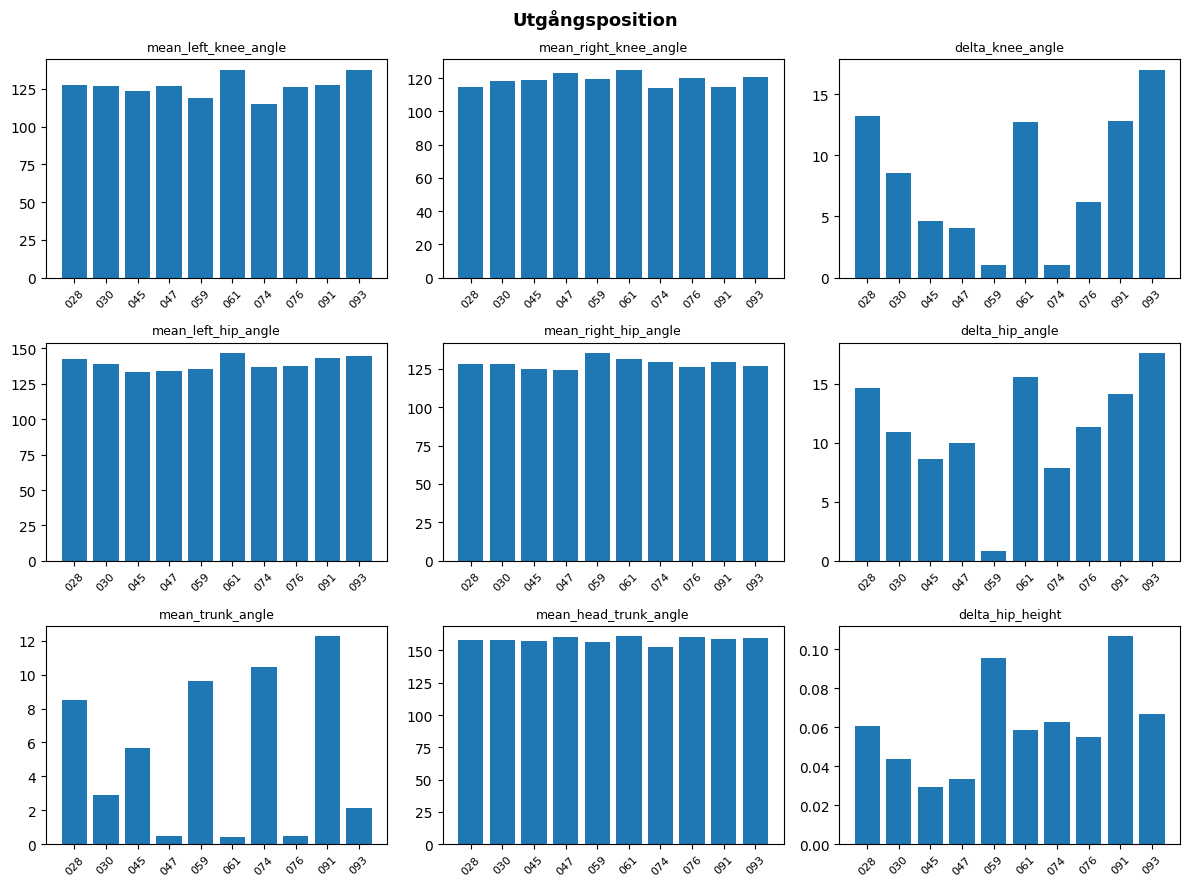

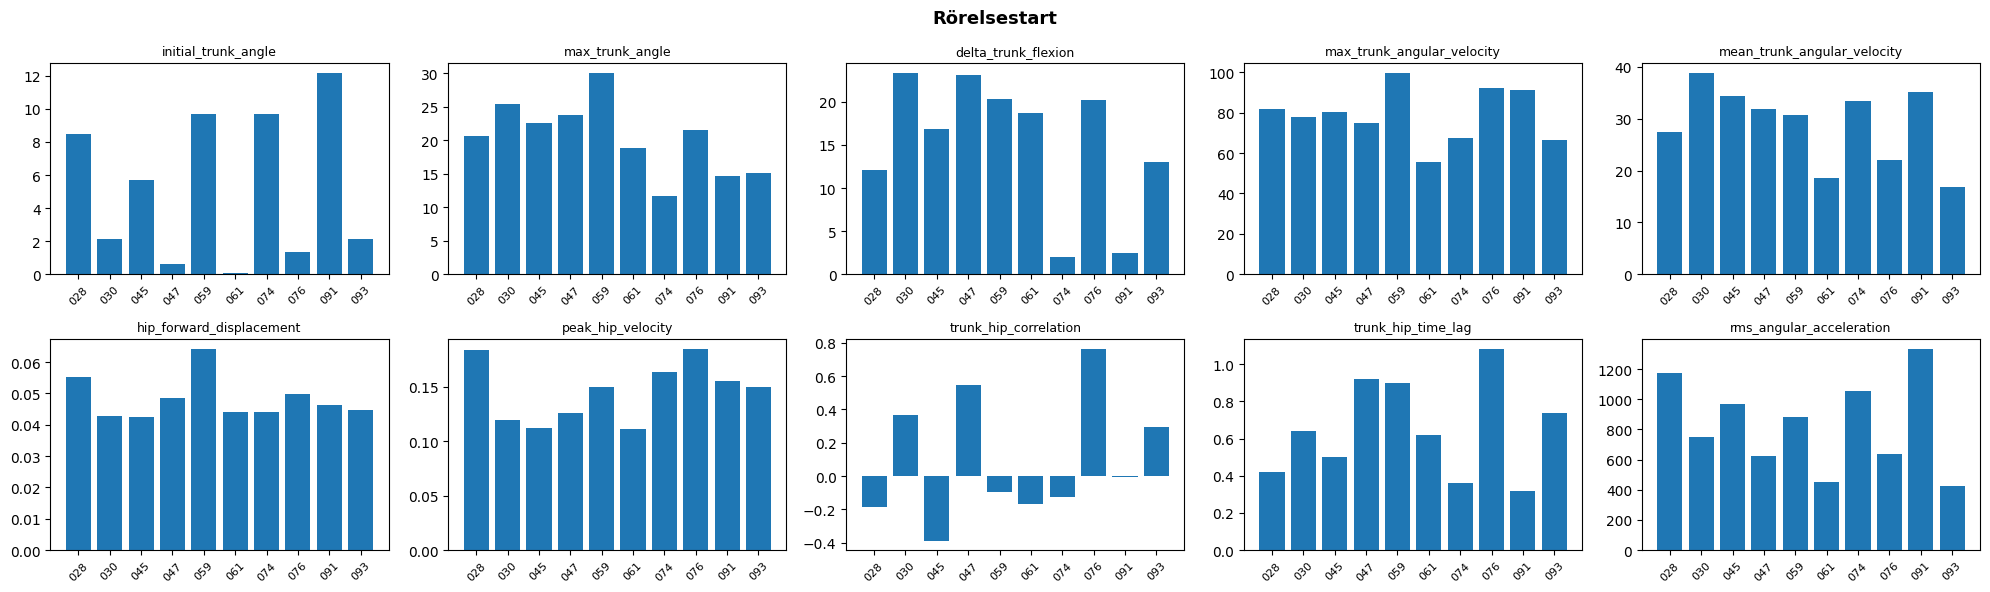

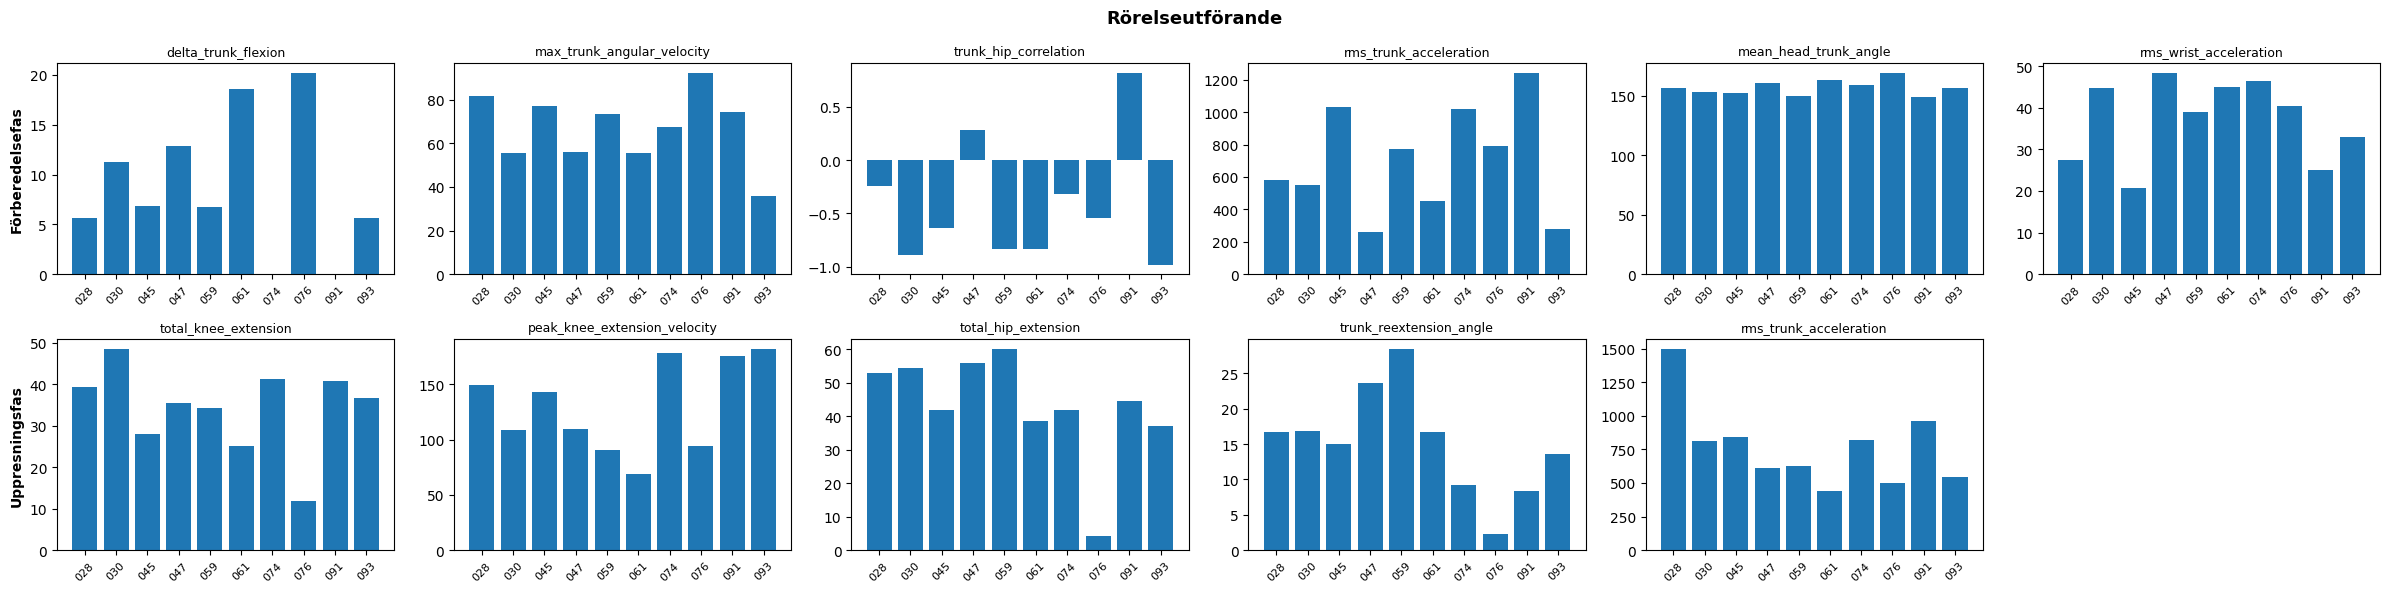

In [33]:
def plot_phase(df, title, ncols, filepath):
    features = df.columns.tolist()
    nrows = (len(features) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i, feat in enumerate(features):
        axes[i].bar(df.index, df[feat])
        axes[i].set_title(feat, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fig.savefig(filepath, dpi=150)
    plt.show()

plot_phase(df_utgång, 'Utgångsposition', ncols=3, filepath=OUT_DIR / 'utgångsposition.png')
plot_phase(df_rörelse, 'Rörelsestart',   ncols=5, filepath=OUT_DIR / 'rörelsestart.png')

# Rörelseutförande: two rows, one per sub-phase
forb_cols = [c for c in df_utf.columns if c.startswith('forb_')]
uppr_cols = [c for c in df_utf.columns if c.startswith('uppr_')]
ncols = max(len(forb_cols), len(uppr_cols))

fig, axes = plt.subplots(2, ncols, figsize=(4 * ncols, 6))
for i, feat in enumerate(forb_cols):
    axes[0, i].bar(df_utf.index, df_utf[feat])
    axes[0, i].set_title(feat.replace('forb_', ''), fontsize=9)
    axes[0, i].tick_params(axis='x', rotation=45, labelsize=8)
for i, feat in enumerate(uppr_cols):
    axes[1, i].bar(df_utf.index, df_utf[feat])
    axes[1, i].set_title(feat.replace('uppr_', ''), fontsize=9)
    axes[1, i].tick_params(axis='x', rotation=45, labelsize=8)
for j in range(len(uppr_cols), ncols):
    axes[1, j].set_visible(False)

axes[0, 0].set_ylabel('Förberedelsefas', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Uppresningsfas',  fontsize=10, fontweight='bold')
fig.suptitle('Rörelseutförande', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUT_DIR / 'rörelseutförande.png', dpi=150)
plt.show()